# 第 1 周 a｜数据初探：认识 PRIME-CVD 队列

> **本周怎么学**：先学这份**精讲**（手把手、讲概念），再做 `w01b_data_literacy.ipynb`（**工程实践**：用项目的数据模块做字段校验、写数据字典）。

**这一节学什么**
- 用 pandas 读入数据，看清数据的"长相"：多少人、多少变量、每个变量是什么类型
- 检查缺失值，做基本的描述统计
- 用直方图看变量分布，发现数据里的"小秘密"（比如截断）
- 理解生存分析的两个核心概念：**随访时间**和**删失**

**用到的数据**：Data Asset 1（干净版，每人一行，共 5 万人）

**使用方法**：从上到下依次运行每个代码格（快捷键 `Shift + Enter`）。建议先猜一猜输出会是什么，再看结果。

## 0. 准备工作：导入工具包

- `pandas`：处理表格数据，数据科学里最常用的包
- `numpy`：数值计算
- `matplotlib`：画图
- 开头几行 `ROOT = ...` 是在向上寻找项目根目录，这样无论从哪个文件夹打开笔记本，都能找到数据和 `primecvd` 包
- `primecvd.paths`：项目自带的路径工具（`primecvd/paths.py`），告诉你数据文件在哪里
- `primecvd.pubplot`：本项目的**顶刊风格作图工具箱**（`primecvd/pubplot.py`），统一字体、尺寸、配色和导出格式。想学可视化的话，这个文件值得通读

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
import sys
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "run.py").exists())  # 向上找项目根目录
sys.path.insert(0, str(ROOT))

from primecvd import paths                 # 数据与输出路径（primecvd/paths.py）
from primecvd import pubplot as pp         # 顶刊风格作图工具箱（值得通读：primecvd/pubplot.py）
pp.setup()

pd.set_option("display.max_columns", 20)   # 表格最多显示 20 列
pd.set_option("display.float_format", "{:.2f}".format)   # 小数统一显示 2 位（避免科学计数法）

## 1. 读入数据

`pd.read_csv()` 把 CSV 文件读成一个 **DataFrame**（数据框），可以理解成 Python 里的 Excel 表格。

In [2]:
df = pd.read_csv(paths.ASSET1)

print("数据文件：", paths.ASSET1.relative_to(paths.ROOT))
print("数据形状（行数, 列数）：", df.shape)

数据文件： data/raw/asset1.csv
数据形状（行数, 列数）： (50000, 12)


`asset1.csv` 就是 Figshare 上的 `Data001_ReadyForCoxPH_v2(2026-08-12).csv`：下载器（`python run.py download`）统一改了文件名，并把来源、版本和 MD5 核验结果记录在 `data/raw/manifest.json` 里。

5 万行、12 列：**每一行是一个人，每一列是一个变量**。用 `.head()` 看前 5 行：

In [3]:
df.head()

,IRSD_quintile,Age,smoking_status,BMI,diabetes,CKD,HbA1c,eGFR,SBP,AF,cvd_event,cvd_time
0,4,50.40,non,28.17,0,0,4.32,83.08,118.67,0,1,2.96
1,3,39.23,ex,16.83,0,0,4.70,81.49,123.72,0,0,4.41
2,5,55.49,non,23.52,0,0,3.67,86.78,126.65,0,0,4.49
3,4,51.91,non,31.98,0,0,4.49,94.70,113.89,0,0,4.89
4,1,47.09,ex,25.35,0,0,4.32,86.34,125.91,0,0,4.49


各列的含义（完整说明见 [docs/04_data_dictionary.md](../docs/04_data_dictionary.md)）：

| 列名 | 含义 | 类型 |
|---|---|---|
| `IRSD_quintile` | 社会经济劣势指数五分位，**1 = 最贫困，5 = 最富裕** | 有序分类 |
| `Age` | 基线年龄（岁） | 连续 |
| `smoking_status` | 吸烟状态：non 从不 / ex 已戒 / current 现在吸 | 分类 |
| `BMI` | 体重指数（kg/m²） | 连续 |
| `diabetes`, `CKD`, `AF` | 是否患糖尿病 / 慢性肾病 / 房颤（1 = 是，0 = 否） | 二分类 |
| `HbA1c` | 糖化血红蛋白（%） | 连续 |
| `eGFR` | 估算肾小球滤过率（mL/min/1.73m²），越低肾功能越差 | 连续 |
| `SBP` | 收缩压（mmHg） | 连续 |
| `cvd_event` | **结局**：随访期间是否发生心血管事件（1 = 是） | 二分类 |
| `cvd_time` | **随访时间**：从基线到发生事件或随访结束的年数 | 连续 |

## 2. 变量类型：数据类型 ≠ 统计类型

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   IRSD_quintile   50000 non-null  int64  
 1   Age             50000 non-null  float64
 2   smoking_status  50000 non-null  object 
 3   BMI             50000 non-null  float64
 4   diabetes        50000 non-null  int64  
 5   CKD             50000 non-null  int64  
 6   HbA1c           50000 non-null  float64
 7   eGFR            50000 non-null  float64
 8   SBP             50000 non-null  float64
 9   AF              50000 non-null  int64  
 10  cvd_event       50000 non-null  int64  
 11  cvd_time        50000 non-null  float64
dtypes: float64(6), int64(5), object(1)
memory usage: 4.6+ MB


`int64` 是整数，`float64` 是小数，`object` 是文本。

⚠️ **初学者最常踩的坑**：`diabetes`、`cvd_event` 在电脑里存成整数，但它们其实是**是/否**的二分类变量；`IRSD_quintile` 存成 1–5 的整数，但它是**有序分类**，"5"并不代表比"1"多 5 倍。算"平均 IRSD"就没有意义。分析之前，先想清楚每个变量的**统计类型**。

## 3. 缺失值检查

拿到任何数据，第一件事都应该是看有没有缺失。`.isna()` 判断每个格子是否缺失，`.sum()` 按列加总。

In [5]:
df.isna().sum()

IRSD_quintile     0
Age               0
smoking_status    0
BMI               0
diabetes          0
CKD               0
HbA1c             0
eGFR              0
SBP               0
AF                0
cvd_event         0
cvd_time          0
dtype: int64

干净版没有任何缺失值。真实的医院数据不会这么友好，第 10 周里我们就会遇到。

## 4. 连续变量：描述统计

`.describe()` 一次性给出计数、均值、标准差、最小值、四分位数和最大值。加 `.T` 把表格转置，读起来更方便。

In [6]:
continuous = ["Age", "BMI", "SBP", "HbA1c", "eGFR", "cvd_time"]
df[continuous].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,50000.00,49.71,12.37,18.00,41.33,49.63,58.09,90.00
BMI,50000.00,28.33,5.03,15.00,24.92,28.33,31.73,52.76
SBP,50000.00,123.31,16.10,55.85,112.39,123.14,134.10,187.79
HbA1c,50000.00,4.79,0.93,2.23,4.24,4.66,5.12,12.71
eGFR,50000.00,82.77,6.09,37.00,79.22,82.94,86.66,104.65
cvd_time,50000.00,4.80,0.80,0.00,4.49,4.88,5.25,7.31


**怎么读这张表**
- `mean` 均值、`std` 标准差：描述"中心"和"离散程度"
- `25%`、`50%`（中位数）、`75%`：如果均值和中位数差得多，说明分布是偏的
- `min`、`max`：先检查**临床上合不合理**，这是发现数据错误最快的办法

🤔 **想一想**：`Age` 的最小值正好是 18，最大值正好是 90；`BMI` 的最小值正好是 15.0。这么"整齐"的数字说明什么？（第 6 节揭晓）

## 5. 分类变量：频数和百分比

In [7]:
categorical = ["smoking_status", "IRSD_quintile", "diabetes", "CKD", "AF", "cvd_event"]

for col in categorical:
    counts = df[col].value_counts().sort_index()
    table = pd.DataFrame({
        "人数": counts,
        "百分比(%)": (counts / len(df) * 100).round(1),
    })
    print(f"—— {col} ——")
    print(table, "\n")

—— smoking_status ——
                   人数  百分比(%)
smoking_status               
current          5067   10.10
ex               8361   16.70
non             36572   73.10 

—— IRSD_quintile ——
                  人数  百分比(%)
IRSD_quintile               
1              10640   21.30
2               8055   16.10
3              11941   23.90
4               8495   17.00
5              10869   21.70 

—— diabetes ——
             人数  百分比(%)
diabetes               
0         46283   92.60
1          3717    7.40 

—— CKD ——
        人数  百分比(%)
CKD               
0    49660   99.30
1      340    0.70 

—— AF ——
       人数  百分比(%)
AF               
0   49640   99.30
1     360    0.70 

—— cvd_event ——
              人数  百分比(%)
cvd_event               
0          47991   96.00
1           2009    4.00 



**观察**
- 吸烟：约 73% 从不吸烟，10% 现在吸烟
- 糖尿病患病率约 7.4%；CKD 和房颤都不到 1%，属于**少见病**，后面分析时它们的估计会不太稳定
- 随访期间约 **4.0%** 的人发生了心血管事件（2009 人）

## 6. 看分布：直方图

数字表格容易漏掉细节，画图能一眼看出分布的形状。下面把 6 个连续变量画在一张图里（这种排法叫"小多图"，small multiples）。

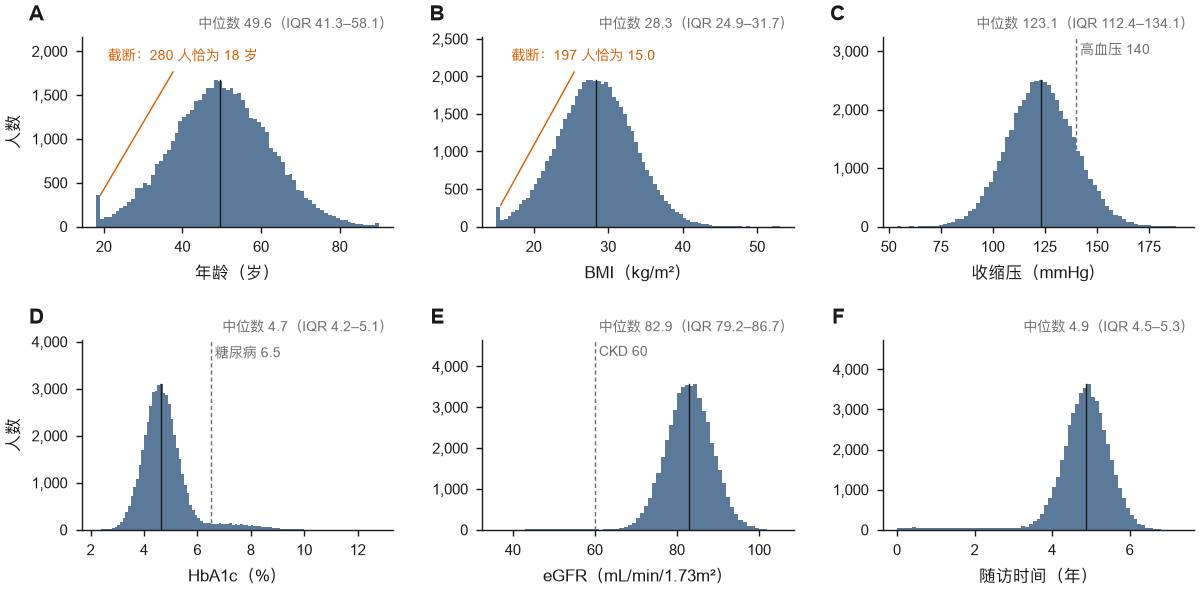

In [8]:
# 每个面板：(列名, 轴标题, 直方图分箱, 临床参考线)
panels = [
    ("Age", "年龄（岁）", np.arange(18, 91, 1), None),
    ("BMI", "BMI（kg/m²）", np.arange(15, 53.5, 0.5), None),
    ("SBP", "收缩压（mmHg）", np.arange(54, 192, 2), (140, "高血压 140")),
    ("HbA1c", "HbA1c（%）", np.arange(2.2, 12.8, 0.1), (6.5, "糖尿病 6.5")),
    ("eGFR", "eGFR（mL/min/1.73m²）", np.arange(36, 106, 1), (60, "CKD 60")),
    ("cvd_time", "随访时间（年）", np.arange(0, 7.4, 0.1), None),
]

fig, axes = plt.subplots(2, 3, figsize=pp.size(pp.DOUBLE, 92))   # 双栏：宽 183 mm × 高 92 mm
for ax, letter, (col, xlabel, bins, ref) in zip(axes.flat, "ABCDEF", panels):
    x = df[col]
    counts, _, _ = ax.hist(x, bins=bins, color=pp.NEUTRAL, lw=0)
    ax.set_ylim(0, counts.max() * 1.3)                  # 顶部留白：注释放在柱子上方，不压数据
    med, q1, q3 = x.median(), x.quantile(0.25), x.quantile(0.75)
    ax.axvline(med, ymax=counts.max() / ax.get_ylim()[1], color=pp.INK, lw=0.6)
    # 汇总统计放在坐标区外、面板标号同一行的右侧：图内只留数据和必要注释
    ax.text(1, 1.03, f"中位数 {med:.1f}（IQR {q1:.1f}–{q3:.1f}）", transform=ax.transAxes,
            ha="right", va="bottom", fontsize=6, color=pp.GREY)
    if ref:
        pp.ref_line(ax, ref[0], label=ref[1], label_pos=0.97)
    ax.set_xlabel(xlabel)
    pp.thousands_axis(ax)
    pp.panel_label(ax, letter)
for ax in axes[:, 0]:
    ax.set_ylabel("人数")

# 只标注最值得注意的发现：截断造成的堆积（用醒目的朱红色）
n18, n15 = (df["Age"] == 18).sum(), (df["BMI"] == 15).sum()
for ax, x0, n, text, tx in [(axes[0, 0], 18.5, n18, f"截断：{n18} 人恰为 18 岁", 21),
                            (axes[0, 1], 15.25, n15, f"截断：{n15} 人恰为 15.0", 17)]:
    ax.annotate(text, xy=(x0, n + 30), xytext=(tx, 0.9), textcoords=("data", "axes fraction"),
                fontsize=6, color=pp.EXPOSED, va="center",
                arrowprops=dict(arrowstyle="-", color=pp.EXPOSED, lw=0.6))

fig.tight_layout(w_pad=2.2, h_pad=1.6)
pp.save(fig, "01_distributions")
plt.show()

🎨 **设计要点**
- **按印刷尺寸作图**：`pp.size(pp.DOUBLE, 92)` 就是期刊双栏宽度 183 mm。字号直接用 6–7.5 pt 设定，印出来就是这么大，不会因为缩放变得看不清
- **颜色克制**：只有一组数据，就用一种低饱和的灰蓝；唯一的醒目色（朱红）留给需要读者注意的截断注释
- **面板标号 A–F**：正文里可以写"见图 1D"，读者一下就能找到
- **汇总统计放在坐标区外**：中位数和 IQR 写在面板右上方，图内只留数据
- **临床阈值参考线**：高血压 140 mmHg、糖尿病 HbA1c 6.5%、CKD eGFR 60。线条细、颜色灰、用虚线，帮读者看出"有多少人越过了临床界值"，又不抢数据的风头
- **图里不写大标题**：期刊把标题写在**图注**里。下面是这张图的图注示范：

> **图 1｜基线连续变量的分布（N = 50,000）。** 竖实线为中位数，右上方给出中位数和四分位间距（IQR）；灰色虚线为临床阈值。A、B 中的朱红色标注指出模拟时截断造成的堆积。

**观察**
- `Age`：左右两端各有一根突起的"柱子"。`BMI` 在 15 处也有一根
- `HbA1c`：右边拖着一条长尾巴（**右偏**），主要来自糖尿病患者
- `eGFR`：大部分在 70–95 之间，左边有少数肾功能差的人

下面数一数正好落在边界上的人：

In [9]:
print("年龄正好 = 18 岁：", (df["Age"] == 18).sum(), "人")
print("年龄正好 = 90 岁：", (df["Age"] == 90).sum(), "人")
print("BMI 正好 = 15.0：", (df["BMI"] == 15).sum(), "人")

年龄正好 = 18 岁： 280 人
年龄正好 = 90 岁： 30 人
BMI 正好 = 15.0： 197 人


连续变量里出现几百个一模一样的值，几乎可以肯定是**截断（clipping）**：模拟时超出范围的值被强行设成了边界值。真实数据里也常见类似情况，比如仪器量程上限、数据库只记录"≥ 90 岁"。

👉 **经验**：发现"堆积"在某个整数值上的现象时，要追问一下它是怎么产生的。

## 7. 结局变量：CVD 事件与随访时间

这份数据是一个**队列研究**：所有人在基线（2017 年 1 月）进入研究，然后被追踪观察。每个人的结局用**两列**记录：

- `cvd_event = 1`：观察到了心血管事件，`cvd_time` 是**事件发生的时间**
- `cvd_event = 0`：到观察结束都没发生事件，`cvd_time` 是**随访结束的时间**。这种情况叫**删失（censoring）**：我们只知道他"至少在这段时间内没发病"，之后怎样不知道

举个例子：

| 病人 | cvd_time | cvd_event | 含义 |
|---|---|---|---|
| A | 2.1 | 1 | 第 2.1 年发生了心血管事件 |
| B | 5.0 | 0 | 观察了 5 年，一直没发病（删失） |
| C | 3.2 | 0 | 观察到第 3.2 年就失访了，之前没发病（删失） |

In [10]:
df.groupby("cvd_event")["cvd_time"].describe()

,count,mean,std,min,25%,50%,75%,max
cvd_event,,,,,,,,
0,47991.00,4.90,0.54,2.68,4.54,4.90,5.27,7.31
1,2009.00,2.28,1.46,0.00,1.02,2.13,3.44,6.08


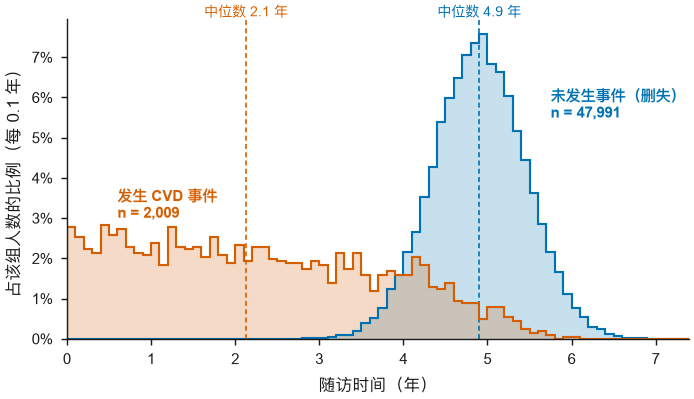

In [11]:
fig, ax = plt.subplots(figsize=pp.size(pp.ONE_HALF, 62))      # 1.5 栏：宽 120 mm
bins = np.arange(0, 7.5, 0.1)
for value, color in [(0, pp.REFERENCE), (1, pp.EXPOSED)]:
    t = df.loc[df["cvd_event"] == value, "cvd_time"]
    w = np.full(len(t), 1 / len(t))   # 每组各自换算成比例：两组人数差 24 倍，也能直接比较分布"形状"
    ax.hist(t, bins=bins, weights=w, histtype="stepfilled", color=color, alpha=0.22, lw=0)
    ax.hist(t, bins=bins, weights=w, histtype="step", color=color, lw=0.9)
    med = t.median()
    ax.axvline(med, color=color, lw=0.7, ls=(0, (3, 2)))
    ax.text(med, 1.0, f"中位数 {med:.1f} 年", transform=ax.get_xaxis_transform(),
            color=color, fontsize=6, ha="center", va="bottom")

# 直接标注（direct labeling）：组名写在分布旁边，读者不用在图例和图形之间来回对照
n_event, n_censor = int(df["cvd_event"].sum()), int((df["cvd_event"] == 0).sum())
ax.text(0.6, 0.029, f"发生 CVD 事件\nn = {n_event:,}", color=pp.EXPOSED,
        fontsize=6.5, fontweight="bold", va="bottom")
ax.text(5.75, 0.055, f"未发生事件（删失）\nn = {n_censor:,}", color=pp.REFERENCE,
        fontsize=6.5, fontweight="bold")
ax.set_xlim(0, 7.4)
ax.set_xlabel("随访时间（年）")
ax.set_ylabel("占该组人数的比例（每 0.1 年）")
pp.percent_axis(ax)
pp.save(fig, "01_followup_by_event")
plt.show()

🎨 **设计要点**
- **两组放在同一个坐标里**，比左右分开的两张图更容易比较；用"阶梯线 + 浅色填充"，重叠的部分也能看清
- **各组分别归一化**：纵轴是"占本组人数的百分比"。如果直接画人数，2,009 人的事件组会被 47,991 人的删失组压成一条贴地的线
- **颜色有固定含义**：全项目中**朱红 = 发生事件 / 暴露组，蓝 = 未发生事件 / 参照组**。读者看过一张图后，后面的图不用再看图例

> **图 2｜按结局分组的随访时间分布。** 各组分别归一化为该组人数的百分比；虚线为各组中位数。

发生事件的人随访时间明显更短（中位数约 2.1 年，没发生事件的人约 4.9 年）。这很自然：事件一发生，这个人的"观察"就结束了。

所以**不能只比较"发病的比例"**：观察 1 年和观察 7 年的人，发病机会完全不一样。第 2 周会引入"人年发病率"，第 5–6 周会用生存分析来正确处理这个问题。

## 8. 一个初步的比较：糖尿病与 CVD 事件

`groupby` 是 pandas 最有用的功能之一：**按某个变量分组，然后对每组计算统计量**。

In [12]:
by_diabetes = df.groupby("diabetes")["cvd_event"].agg(人数="count", 事件数="sum", 事件比例="mean")
by_diabetes["事件比例"] = (by_diabetes["事件比例"] * 100).round(1).astype(str) + "%"
by_diabetes

,人数,事件数,事件比例
diabetes,,,
0,46283,810,1.8%
1,3717,1199,32.3%


糖尿病患者的事件比例（约 32%）远高于非糖尿病者（约 1.8%）。但先别急着下结论：**糖尿病患者也更老、血压更高**，这些因素本身也会增加风险。这就是**混杂（confounding）**。第 2 周和第 5–6 周会一步步处理它。

## 小结

| 学到的操作 | 代码 |
|---|---|
| 读数据 | `pd.read_csv()` |
| 看形状和前几行 | `.shape`、`.head()` |
| 看变量类型 | `.info()` |
| 查缺失 | `.isna().sum()` |
| 描述统计 | `.describe()`、`.value_counts()` |
| 分组统计 | `.groupby(...).agg(...)` |

**核心概念**：数据类型 vs 统计类型、截断、随访时间、删失、混杂

## 练习（答案不唯一，动手试试）

1. 用 `df.groupby("smoking_status")["cvd_event"].mean()` 看不同吸烟状态的事件比例。已戒烟（ex）的人为什么风险没有比"从不吸烟"低？（提示：想想谁会去戒烟）
2. 分别计算男女……等等，这份数据里有性别变量吗？真实的心血管风险模型通常必须包含性别，缺少它意味着什么？
3. 从数据里随机抽 2000 人（`df.sample(2000, random_state=1)`），画 `Age` 和 `SBP` 的散点图。两者有关系吗？试着用 `pp.size(pp.SINGLE, 70)` 按单栏尺寸画，点用 `pp.NEUTRAL`、透明度 `alpha=0.3`，避免点重叠成一团